# Heart Disease Classifier

This project aims to build a neural network that can accurately predict who has heart disease based on the data in the [UCI heart disease](https://archive.ics.uci.edu/dataset/45/heart+disease) dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch as pt
import numpy as np
from sklearn.impute import KNNImputer

## About the Data

There are 14 attributes in this dataset, some numerical and some categorical. 

The numerical values are:
- age in years
    - older age means increased risk of heart disease as [arteries naturally stiffen, heart walls thicken, and valves calcify](https://cvhealthclinic.com/news/how-does-age-affect-heart-health/)
- resting blood pressure on admission to hospital (trestbps)
    - consistently elevated resting bp forces the heart to work harder, increasing risk of heart disease
- serum cholesterol in mg/dl (chol)
    - high serum cholesterol is linked to heart disease
- maximum heart rate achieved in beats per minute (bpm) during a maximal stress test (thalach)
    - low maximum heart rate achieved during an exercise test for one's age can be correlated with presence of heart disease as the heart pumps less efficiently and may struggle to increase its rate under stress when there are blockages or restricted blood flow
- ST depression induced by exercise relative to rest (oldpeak)
    - ST segment in ECG represents the period when the ventricles of the heart are fully depolarized and preparing to repolarize (i.e. the ventricles are fully contracted, pumping blood out of the heart)
    - ST segment is usually flat on the ECG but if it's depressed during the cardiac stress test, it typically means the heart isn't receiving enough oxygen (myocardial ischemia), indicating heart disease
    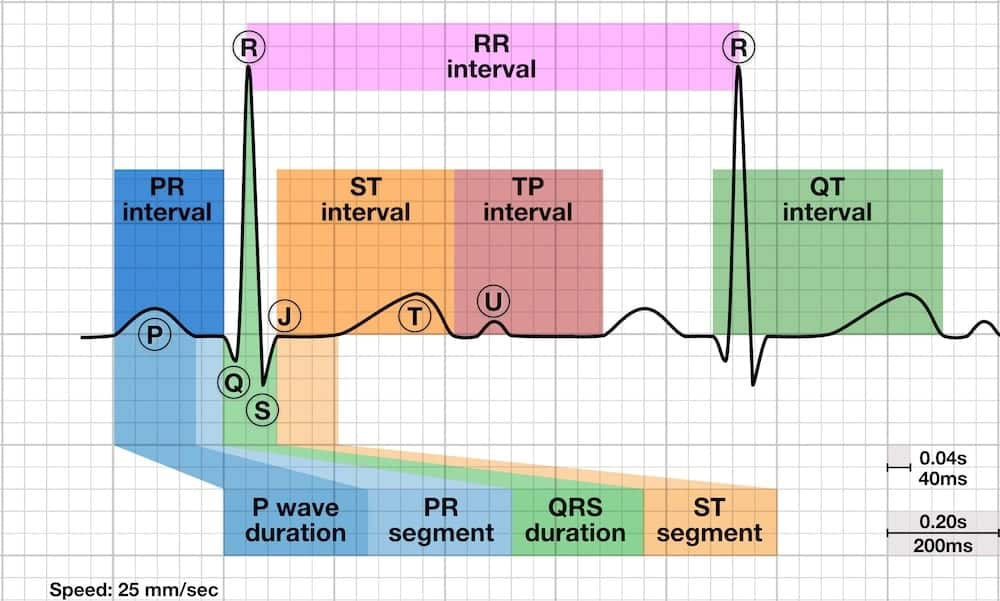
    - oldpeak is measured in mm or mV and quantifies how much the ST segment in an ECG dips below baseline during an exercise stress test compared to resting state (values > 1-2mm often point toward myocardial ischemia)
- number of major coronary vessels (0-3) colored by fluoroscopy (ca)
    - higher count generally indicates healthier blood flow and lower risk of heart disease
- diagnosis of heart disease (num: 0 or 1, where 0 is negative for heart disease and 1 is positive)

The categorical values are:
- sex (male/female)
    - men typically experiences heart disease earlier than women and have higher overall rates, but women's risk sharply increases after menopause when estrogen levels drop
- chest pain type (cp: typical angina, atypical angina, non-anginal, asymptomatic)
    - typical angina: substernal chest discomfort (squeezing, pressure, fullness) that is predictably triggered by physical exertion or emotional stress and relieved by rest or nitroglycerin -> highest probability of heart disease
    - atypical angina: involves two of the typical angina characteristics but is often more diffuse; may present as pain radiating only to the back or jaw, sharp discomfort, or shortness of breath -> moderate probability of heart disease
    - non-anginal chest pain: does not meet the typical angina criteria; usually sharp, fleeting, or worsens with touch, breathing, or twisting -> low probability of heart disease and may be caused by other issues such as GERD, anxiety, or musculoskeletal issues
    - asymptomatic: lack of chest pain at all; must look at other attributes to determine heart disease risk
- fasting blood sugar > 120 mg/dl (fbs: T/F)
    - indicatews prediabetes which significantly increases long-term risk of developing heat disease because if your body struggles to process glucose efficiently, it leads to excess glucose in the blood which causes blood vessels to become stiff and narrow over time
    - prediabetes also frequently occurs alongside other cardiac risk factors like high bp and unhealthy cholesterol levels
- resting echocardiographic results (restecg: normal, stt abnormality, or lv hypertrophy)
    - normal: heart's electrical system is functioning properly
    - stt abnormality: an abnormality in the ST-T wave portion of the ECG which represents ventricular repolarization (so there is an abnormality in ventricular repolarization)
        - ST segment represents when the ventricle is fully contracted and the T wave represents when the ventricle is relaxing
        - can indicate myocardial ischemia, high blood pressure (left ventricular hypertrophy), electrolyte imbalances, or a normal variant
    - lv hypertrophy (left ventricle hypertrophy) is the thickening of the heart's left ventricle which pumps oxygenated blood to the body, which stiffens the heart, greatly increasing risk of heart failure and arrhythmias
        - a consequence of ongoing heart disease and an independent risk factor for future cardiac events
- exercise induced angina (exang: T/F)
    - primary symptom of heart disease
- slope of the peak exercise ST segment (slope: upsloping, flat, or downsloping)
    - flat is normal, downsloping indicates myocardial ischemia (explained above), upsloping can sometimes indicate ischemia but is generally considered benign or false-positive if steep
- thallium stress test result (thal: normal, fixed defect, or reversible defect)
    - thallium stress test evaluates your heart's blood flow using a radioactive tracer and a gamma camera, tracking how well blood pumps through your heart:
        - normal result: even, healthy blood flow in all areas of the heart during rest and stress phases
        - reversible defect: blood flow is normal at rest but decreases during exercise or stress, indicating blocked or narrowed coronary artery
        - fixed defect: blood flow is reduced in certain areas of the heart during both rest and exercise; if no thallium is visible in a segment of the heart it typically means permanent damage or scarring from a previous heart attack

Also included are unique ids for each patient and the place where each patient was studied (origin), resulting in a total of 16 columns.

## Data Prep & Exploratory Analysis

### Load Data

In [2]:
df = pd.read_csv('heart_disease_uci.csv')
df

,id,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


### Check for missing values, duplicates, if all IDs are unqiue

In [3]:
df.info()  # dtypes are correct

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   origin    920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalach   865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 0


In [89]:
# check if all ids are unique
unique_id = df['id'].is_unique
print('\nUnique IDs:', unique_id)


Unique IDs: True


In [90]:
print('Percentage of data missing')
(df.isna().mean() * 100).round(2).astype(str) + '%'

Percentage of data missing


id            0.0%
age           0.0%
sex           0.0%
origin        0.0%
cp            0.0%
trestbps     6.41%
chol         3.26%
fbs          9.78%
restecg      0.22%
thalach      5.98%
exang        5.98%
oldpeak      6.74%
slope       33.59%
ca          66.41%
thal        52.83%
num           0.0%
dtype: str

### Impute or drop rows/columns with missing data

In [91]:
pct_rows_with_missing = df.isna().any(axis=1).mean()
print(f"{pct_rows_with_missing * 100:.2f}% of rows have missing data")

67.50% of rows have missing data


Can't just drop all rows with missing data because that's more than half the data, defeating the purpose of using a dataset of this size. and neural networks need lots of data to train well (i.e. not overfit).

There are [3 kinds of missingness](https://www.kaggle.com/code/utkarshsaxenadn/handling-missing-values-mcar-mar-mnar) that affects whether we drop/impute missing data as well as the imputation method we choose:
- Missing Completely At Random (MCAR)
- Missing At Random (MAR)
- Missing Not At Random (MNAR)

#### 1. features that have near-complete data

In [92]:
print(df['restecg'].value_counts())
df[df['restecg'].isna()]

restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64


,id,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
571,572,55,Male,Hungary,typical angina,140.0,295.0,False,NaN,136.0,False,0.0,NaN,NaN,NaN,1
598,599,34,Male,Switzerland,asymptomatic,115.0,0.0,NaN,NaN,154.0,False,0.2,upsloping,NaN,NaN,1


Because restecg is missing in only 0.22% of the data (less than 1-2% of the data), we will drop the rows in which it is missing because it is likely missing completely at random (MCAR). We choose to drop the rows instead of replace the missing values with the mode because we'd artificially inflate the normal category, diluting clinical reality. 

In [98]:
df = df.dropna(subset=['restecg'])
print('Number of rows with missing restecg:', df['restecg'].isna().sum())

Number of rows with missing restecg: 0


#### 2. features that are missing a significant percentage of their values

In [94]:
print('Count of missing SLOPE by origin')
df_na_slope = df[df['slope'].isna()]
print(df_na_slope['origin'].value_counts())

print('\nCount of missing CA by origin')
df_na_ca = df[df['ca'].isna()]
print(df_na_ca['origin'].value_counts())

print('\nCount of missing THAL by origin')
df_na_thal = df[df['thal'].isna()]
print(df_na_thal['origin'].value_counts())

Count of missing SLOPE by origin
origin
Hungary          188
VA Long Beach    102
Switzerland       17
Cleveland          1
Name: count, dtype: int64

Count of missing CA by origin
origin
Hungary          289
VA Long Beach    198
Switzerland      117
Cleveland          5
Name: count, dtype: int64

Count of missing THAL by origin
origin
Hungary          264
VA Long Beach    166
Switzerland       51
Cleveland          3
Name: count, dtype: int64


Because slope, thal, and ca are missing in 33-66% of the data, I'm going to try removing these columns from the dataframe. 

These values are typically missing in certain locations, indicating possible differences in hospital protocols. If this model is to be used in places outside of Cleveland, then we need to train the model on features that are commonly collected across almost every clinic in the world and we don't want to risk it overlearning hospital-specific protocols and using that to predict heart disease instead of the actual biology.

Additionally, slope is often recorded in the oldpeak feature as the amount by which the ST segment is depressed. While oldpeak only accounts for flat (0) or downslope (>0) and not upslope, upslope doesn't indicate myocardial ischemia as well as a downslope, so not including slope is fine because we have oldpeak.

Later, we can compare performance of a model that doesn't use these columns at all vs a model that treats these columns as clinically vital (keeps them).

In [ ]:
df_no_sct = df.drop(columns=['slope', 'ca', 'thal'], inplace=False)

,id,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


#### 3. features that are missing more than 1-2% of their values but less than 33-66%

In [ ]:
# whatever you do, do it on both
df  # has slope, ca, thal
df_no_sct  # has no slope, ca, thal

## Training